In [7]:
import numpy as np
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten
from keras.utils import to_categorical
import matplotlib.pyplot as plt

In [8]:
# Carregar o dataset MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalizar os dados
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# redimensiona
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Converter 
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [9]:
# modelo CNN
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

c:\Program Files\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# compilar o modelo
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# treinar o modelo
model.fit(x_train, y_train, batch_size=128, epochs=5, validation_split=0.1)

# avaliar o modelo
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc:.4f}')

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.9567 - loss: 0.1475 - val_accuracy: 0.9873 - val_loss: 0.0465
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 93ms/step - accuracy: 0.9764 - loss: 0.0763 - val_accuracy: 0.9893 - val_loss: 0.0397
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.9825 - loss: 0.0570 - val_accuracy: 0.9887 - val_loss: 0.0401
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 39s 93ms/step - accuracy: 0.9849 - loss: 0.0466 - val_accuracy: 0.9910 - val_loss: 0.0367
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 89ms/step - accuracy: 0.9874 - loss: 0.0396 - val_accuracy: 0.9908 - val_loss: 0.0307
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9873 - loss: 0.0400
Test accuracy: 0.9899


In [13]:
def color_digits(predictions, x_test):
    # Para cada imagem no conjunto de teste
    colored_images = []
    for i in range(len(predictions)):
        img = x_test[i].reshape(28, 28)
        img_colored = np.zeros((28, 28, 3), dtype=np.uint8)  

        # colorir
        if predictions[i] % 2 == 0:
            img_colored[:, :, 2] = img * 255 
        else:
            img_colored[:, :, 0] = img * 255 

        colored_images.append(img_colored)
    
    return colored_images

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


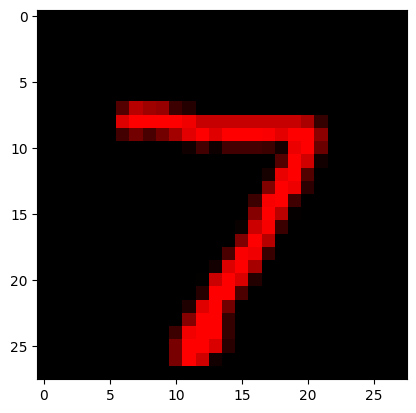

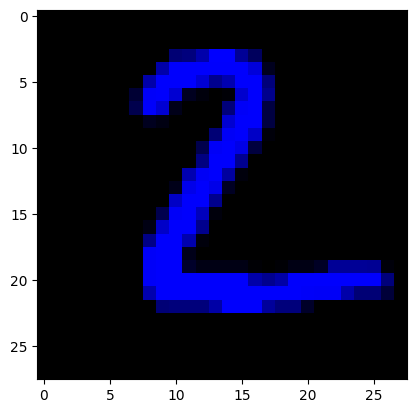

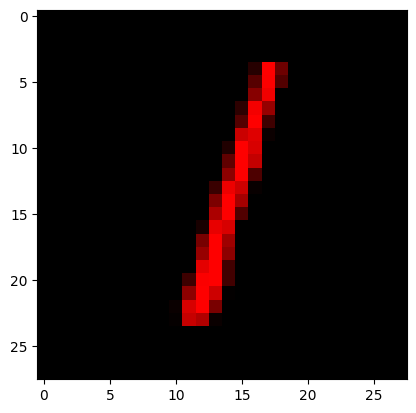

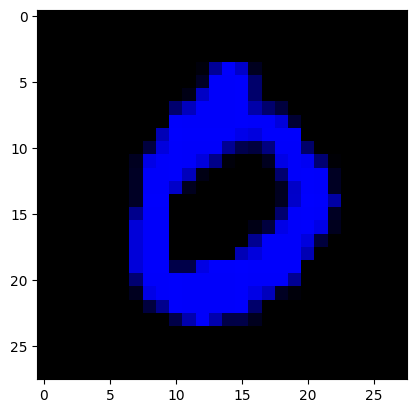

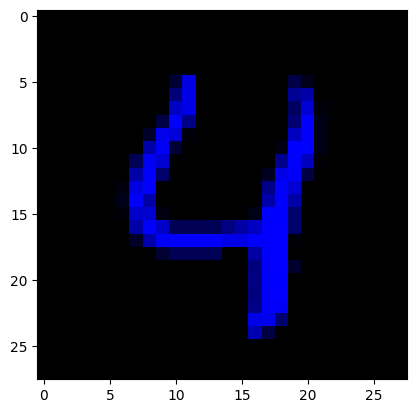

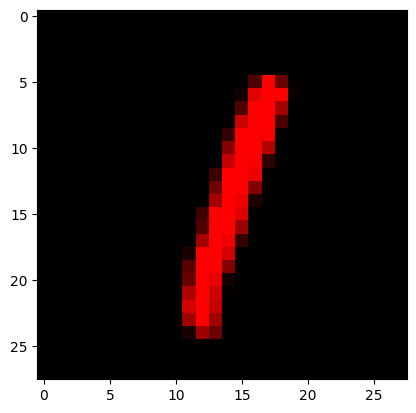

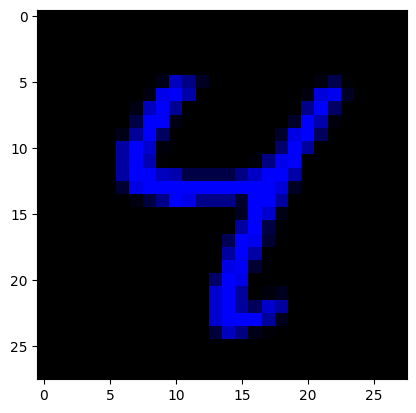

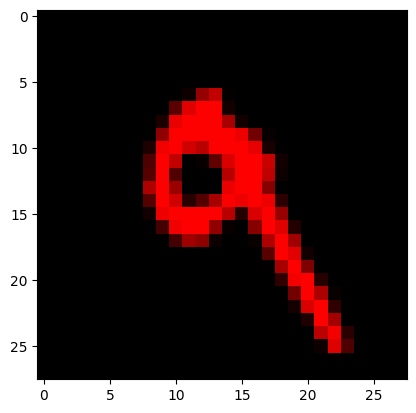

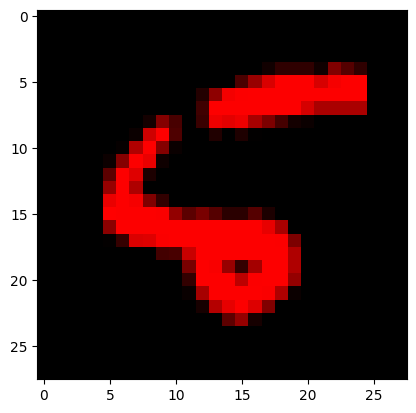

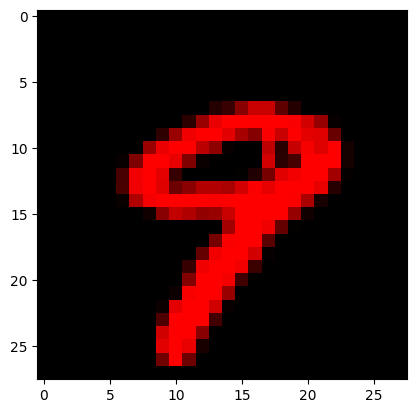

In [15]:
# Prever
predictions = np.argmax(model.predict(x_test), axis=1)

# Colorir 
colored_digits = color_digits(predictions, x_test)

# testar
for i in range(10):
    plt.imshow(colored_digits[i])
    plt.show()